# 03. Stimuli and the round-trip check

This notebook rebuilds the stimuli for one evaluated verse with the paper's own code
(`src/original/confirmation/controls.py`) and the round-trip arms (`src/evaluation/extra_arms.py`):
duration-matched Local, Global and Silence arms (Eq. 1 of the paper) with the phase vocoder (PV) and
Rubber Band (RB), then the stretch-and-restore round trip.

Source audio is not distributed. Set `AUDIO_ROOT` to a local copy of the EveryAyah recordings; the target
intervals are read from the logged CTC alignment, so no recogniser is needed here.

In [1]:
import sys, json, gzip, collections
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src" / "analysis"))
import numpy as np
import stats as S
import os
import matplotlib.pyplot as plt
import librosa, librosa.display
import soundfile as sf
sys.path.insert(0, str(ROOT / "src/original/confirmation")); sys.path.insert(0, str(ROOT / "src/evaluation"))
import controls, extra_arms
import warnings; warnings.filterwarnings("ignore")
AUDIO_ROOT = Path(os.environ.get("AUDIO_ROOT", "/Users/Apple/Desktop/sajlina_train/audio"))
print("Rubber Band CLI:", controls.RUBBERBAND_PATH)

Rubber Band CLI: /opt/homebrew/bin/rubberband


In [2]:
RECITER = "Rifai"
manifest = json.loads((ROOT / "src/original/confirmation/manifest_v2.json").read_text())
with gzip.open(ROOT / "results/tarteel/observations.jsonl.gz", "rt", encoding="utf-8") as fh:
    VERSE = next(r["verse"] for r in map(json.loads, fh) if r["kind"] == "alignment" and r["reciter"] == RECITER)
item = next(f for f in manifest["reciters"][RECITER]["files"] if f["verse"] == VERSE)
path = AUDIO_ROOT / Path(item["path"]).parent.name / Path(item["path"]).name
x, sr = sf.read(path, dtype="float32")
with gzip.open(ROOT / "results/tarteel/observations.jsonl.gz", "rt", encoding="utf-8") as fh:
    align = next(r for r in map(json.loads, fh) if r["kind"] == "alignment" and r["reciter"] == RECITER and r["verse"] == VERSE)
intervals = [(o["start_sample"] / sr, o["end_sample"] / sr) for o in align["occurrences"]]
print(item["reference"]); print("duration", round(len(x) / sr, 2), "s | target intervals (s):", [tuple(round(t, 3) for t in iv) for iv in intervals])

وَنَفْسٍ وَمَا سَوَّاهَا
duration 3.66 s | target intervals (s): [(1.989, 2.13), (2.813, 3.135)]


In [3]:
k = 4.0
arms = controls.make_conditions(x, sr, intervals, k, include_rubberband=True)
rt = extra_arms.roundtrip_conditions(x, sr, intervals, k, include_rubberband=True)
N_k = len(x) + sum(round((k - 1) * (e - s) * sr) for s, e in intervals)
for name in ["nucleus", "global", "silence", "nucleus_rb", "global_rb"]:
    print(f"{name:11s} {len(arms[name]['audio']):7d} samples")
print("all manipulated arms share one length:", len({len(arms[n]["audio"]) for n in ["nucleus", "global", "silence", "nucleus_rb", "global_rb"]}) == 1)
for name in ["nucleus_rt", "global_rt", "nucleus_rt_rb", "global_rt_rb"]:
    print(f"{name:14s} {len(rt[name]['audio']):7d} samples (original {len(x)})")

nucleus       80696 samples
global        80696 samples
silence       80696 samples
nucleus_rb    80696 samples
global_rb     80696 samples
all manipulated arms share one length: True
nucleus_rt       58514 samples (original 58514)
global_rt        58514 samples (original 58514)
nucleus_rt_rb    58514 samples (original 58514)
global_rt_rb     58514 samples (original 58514)


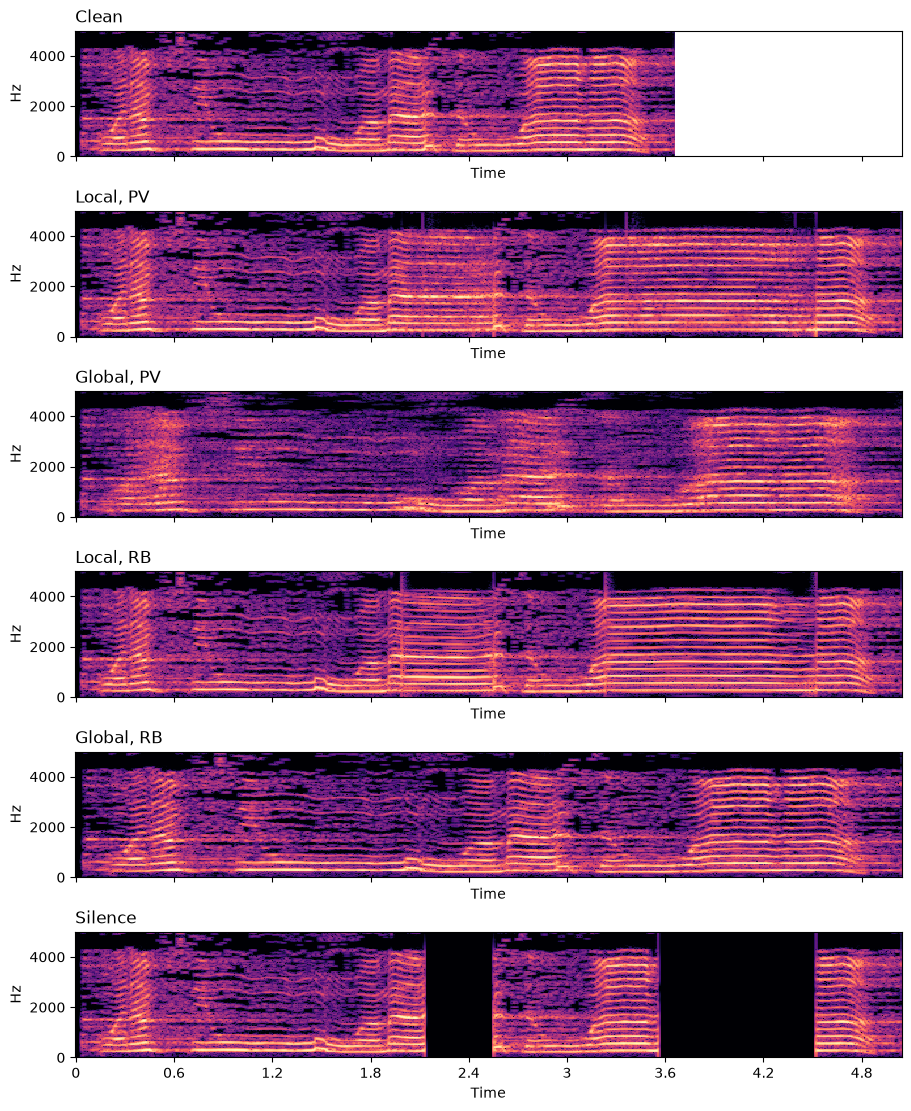

In [4]:
panels = [("Clean", x), ("Local, PV", arms["nucleus"]["audio"]), ("Global, PV", arms["global"]["audio"]),
          ("Local, RB", arms["nucleus_rb"]["audio"]), ("Global, RB", arms["global_rb"]["audio"]), ("Silence", arms["silence"]["audio"])]
fig, axes = plt.subplots(len(panels), 1, figsize=(9, 11), layout="constrained", sharex=True)
for ax, (title, y) in zip(axes, panels):
    S_db = librosa.amplitude_to_db(np.abs(librosa.stft(y, n_fft=512, hop_length=128)), ref=np.max)
    librosa.display.specshow(S_db, sr=sr, hop_length=128, x_axis="time", y_axis="hz", ax=ax, vmin=-70)
    ax.set_title(title, loc="left"); ax.set_ylim(0, 5000)
plt.show()

## Round trip: artifact-only processing at unchanged duration
The difference between the restored signal and the original isolates what the engine does apart from duration. The PV leaves visible smearing across the whole globally processed recording; RB returns a spectrogram close to the original.

global_rt      spectral error energy relative to clean: 0.400
global_rt_rb   spectral error energy relative to clean: 0.023


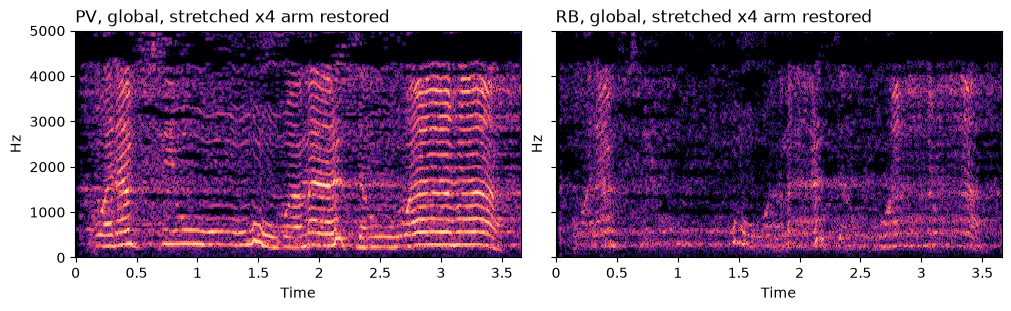

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3), layout="constrained", sharey=True)
ref = np.abs(librosa.stft(x, n_fft=512, hop_length=128))
for ax, (title, key) in zip(axes, [("PV, global, stretched x4 arm restored", "global_rt"), ("RB, global, stretched x4 arm restored", "global_rt_rb")]):
    y = rt[key]["audio"]
    diff = librosa.amplitude_to_db(np.abs(np.abs(librosa.stft(y, n_fft=512, hop_length=128)) - ref) + 1e-6, ref=np.max(ref))
    librosa.display.specshow(diff, sr=sr, hop_length=128, x_axis="time", y_axis="hz", ax=ax, vmin=-70, vmax=0)
    ax.set_title(title, loc="left"); ax.set_ylim(0, 5000)
    print(f"{key:14s} spectral error energy relative to clean: {np.sum((np.abs(librosa.stft(y, n_fft=512, hop_length=128)) - ref) ** 2) / np.sum(ref ** 2):.3f}")
plt.show()